# **Equazioni Differenziali Ordinarie (ODE) - Parte 1: metodi di Eulero**
Consideriamo l'evoluzione temporale di una quantità scalare $y=y(t)\in\mathbb{R}$, la cui dinamica è descritta da un problema di Cauchy della forma:
\begin{equation*}
\begin{cases}
y'(t)=f(t,y(t)) & t_0 \le t\le t_{N},\\ y(0)=y_{0}.
\end{cases}
\end{equation*}
</br>
Per poter risolvere numericamente il problema suddividiamo l'intervallo $I=[t_0,t_N]$ in $N$ sottointervalli con la stessa dimensione data da
</br></br>
\begin{equation*}
h= \dfrac{t_N-t_0}{N}
\end{equation*}
</br>
e definiamo gli istanti discreti $\{t_{0},t_{1},\dots,t_{N}\}$ in cui calcoleremo la soluzione approssimata come
</br></br>
\begin{equation*}
t_n=t_0+nh.
\end{equation*}
</br>
Lo scopo di un metodo numerico per l'equazioni differenziali ordinarie (ODE)  è quello di approssimare la dinamica di $y$ con una sequenza discreta 
$\{u_{0}=y_{0},u_{1},\dots,u_{N}\}$
tale per cui
\begin{equation*}
u_{n}\approx y(t_{n}).
\end{equation*}

## 1. Il metodo di Eulero in avanti </br>
L'idea del metodo di Eulero in avanti è quella di costruire una griglia temporale equispaziata di passo $h>0$ ed approssimare la soluzione del sistema secondo lo schema iterativo sottostante
</br> </br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+hf(t_{n},u_{n}) & n=0,\dots,N-1
\end{cases}
\end{equation*}
</br>
Tale schema è detto *esplicito* e ad un passo (*one-step*), in quanto, ad ogni passo temporale, la soluzione numerica $u_{n+1}$ dipende soltanto dalla soluzione al passo temporale precedente $u_{n}$.

<mark>**Esercizio 1**</mark></br></br>
Scrivere una funzione chiamata $\texttt{eulero\_avanti}$ che, dati $f$, $t_0$, $t_N$, $y_0$ ed $h$, implementi il metodo di Eulero in avanti, restituendo la griglia temporale $\mathbf{t}_h=[t_{0},\dots,t_{N}]$ e la sequenza approssimante $\mathbf{u}_h=[u_{0},\dots,u_{N}]$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def eulero_avanti(f, t0, tN, y0, h):
    """Metodo di Eulero in avanti
    Input:
        f   (lambda function)               Funzione che rappresenta il termine di destra dell'ODE: f(t, y)                    
        t0  (float)                         Tempo iniziale
        tN  (float)                         Tempo finale
        y0  (float,list o numpy.ndarray)    Condizione iniziale: scalare.
        h   (float)                         Passo temporale

    Output:
        t_h   (numpy.ndarray)     Vettore degli istanti temporali (lunghezza N+1).
        u_h   (numpy.ndarray)     Soluzione discreta nei nodi temporali (lunghezza N+1).
    """
    n_intervalli = int((tN - t0) / h) 
    h_ex = (tN - t0) / n_intervalli
    t_h = np.linspace(t0, tN, n_intervalli + 1)
    u_h = [y0]

    for i in range(len(t_h)-1):
        u_h.append(u_h[i] + h_ex*f(t_h[i], u_h[i]))
 
    return t_h, np.array(u_h)

## 2. Il metodo di Eulero all'indietro </br>
In alternativa al metodo di Eulero "in avanti", esiste anche una sua versione "all'indietro", la quale si basa invece sul seguente schema iterativo
</br></br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+hf(t_{n+1},u_{n+1}) & n=0,\dots,N-1
\end{cases}
\end{equation*}
</br>
Tale schema è detto *implicito* e ad un passo (*one-step*), in quanto, ad ogni passo temporale, la soluzione numerica $u_{n+1}$ dipende dalla stessa incongita $u_{n+1}$, oltre che da $u_n$. Quindi, di volta in volta, bisognerà risolvere un'equazione non lineare
\begin{equation*}
z=u_n + h f(t_{n+1}, z)
\end{equation*}
nella variabile incognita $z$. La soluzione di tale equazione si può approssimare, ad esempio, con il metodo del punto fisso.
</br>
</br>
Si osservi che l'utilizzo di un metodo di punto fisso richiede che il modulo della derivata della funzione di iterazione utilizzata sia minore di uno; questa condizione è generalmente soddisfatta per $h$ sufficientemente piccolo.

<mark>**Esercizio 2**</mark></br></br>
Scrivere una funzione chiamata  $\texttt{eulero\_indietro}$ che, dati $f$, $t_0$, $t_N$, $y_0$ ed $h$, implementi il metodo di Eulero all'indietro, restituendo la griglia temporale $\mathbf{t}_h=[t_{0},\dots,t_{N}]$ e la sequenza approssimante $\mathbf{u}_h=[u_{0},\dots,u_{N}]$. Sfruttare il metodo $\texttt{puntofisso}$ che troviamo in $\texttt{utilis\_ODE.py}$

In [4]:
def puntofisso(phi, x0, nmax=100, toll=1.0e-6):
    """
    Metodo del punto fisso (fixed-point iteration).

    Trova il punto fisso dell'equazione x = phi(x) mediante iterazione funzionale.

    Input:
        phi (callable): Funzione di iterazione
        x0 (float): Punto di partenza
        nmax (int): Numero massimo di iterazioni (default: 100)
        toll (float): Tolleranza richiesta (default: 1e-6)

    Output:
        xvect (numpy.ndarray): Vettore delle iterate

    Nota:
        Il metodo converge se |φ'(x*)| < 1 in un intorno del punto fisso x*.
    """
    xvect = [x0]
    xold = x0
    for i in range(nmax):

        xnew = phi(xold)
        xvect.append(xnew)

        if abs(xnew - xold) < toll:
            break
        xold = xnew
    return np.array(xvect)

In [5]:
def eulero_indietro(f, t0, tN, y0, h):
    """Metodo di Eulero all'indietro
    Input:
        f   (lambda function)               Funzione che rappresenta il termine di destra dell'ODE: f(t, y)                    
        t0  (float)                         Tempo iniziale
        tN  (float)                         Tempo finale
        y0  (float,list o numpy.ndarray)    Condizione iniziale: scalare.
        h   (float)                         Passo temporale

    Output:
        t_h   (numpy.ndarray)     Vettore degli istanti temporali (lunghezza N+1).
        u_h   (numpy.ndarray)     Soluzione discreta nei nodi temporali (lunghezza N+1).
    """
    n_intervalli = int((tN - t0) / h)
    h_ex = (tN - t0) / n_intervalli
    t_h = np.linspace(t0, tN, n_intervalli + 1)

    u_h =[y0]



    for i in range(len(t_h) - 1):
        phi = lambda x: u_h[i] + h_ex * f(t_h[i+1], x)
        iterate = puntofisso(phi, u_h[i])
        u_h.append(iterate[-1]) 
    
    return t_h, np.array(u_h)

## 3. Applicazione a un caso esempio

Si consideri il problema di Cauchy
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=\frac{1}{1+t^2}-2y(t)^2 & 0\le t\le 10,\\ y(0)=0,
\end{cases}
\end{equation*}
la cui soluzione esatta è
\begin{equation*}
y(t)=\frac{t}{1+t^{2}}.
\end{equation*}


<mark>**Esercizio 3.1**</mark></br> Rappresentare graficamente la soluzione esatta nell'intervallo considerato.

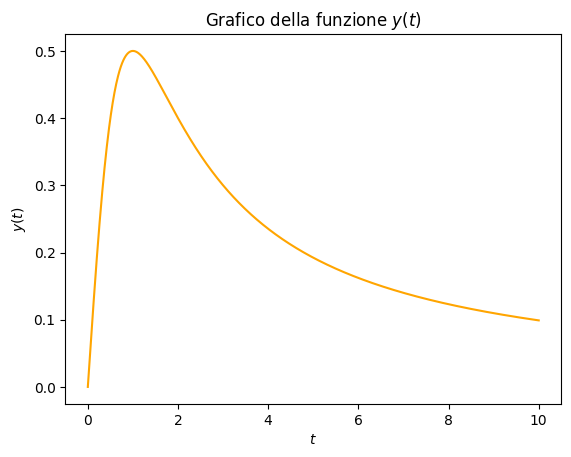

In [27]:
y = lambda t: t / (1 + t**2)
y0 = 0

f = lambda t,y: 1 / (1 + t**2) - 2*y**2

t0, tN = 0, 10
tgrid = np.linspace(t0,tN,1000)

plt.figure()
plt.plot(tgrid, y(tgrid), color = 'orange')
plt.xlabel("$t$")
plt.ylabel("$y(t)$")
plt.title("Grafico della funzione $y(t)$")
plt.show()

<mark>**Esercizio 3.2**</mark></br> Approssimare la soluzione del problema utilizzando il metodo di **Eulero in avanti**, prima con $h=0.2$  e poi con  $h=0.05$. Confrontare graficamente le soluzioni numeriche con la soluzione esatta;

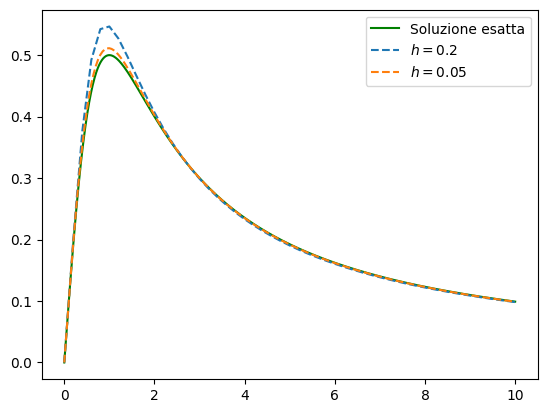

In [34]:
h1, h2 = 0.2, 0.05

t_h1, u_h1_fwd = eulero_avanti(f, t0, tN, y0, h1)
t_h2, u_h2_fwd = eulero_avanti(f, t0, tN, y0, h2)

plt.figure()
plt.plot(tgrid, y(tgrid), color = 'green', label = 'Soluzione esatta')
plt.plot(t_h1, u_h1_fwd, '--', label = '$h = 0.2$')
plt.plot(t_h2, u_h2_fwd,'--', label = "$h = 0.05$")
plt.legend()
plt.show()


<mark>**Esercizio 3.3**</mark></br>
Ripetere il l'**Esercizio 3.2** utilizzando il metodo di **Eulero all'indietro**. Come cambiano i risultati?

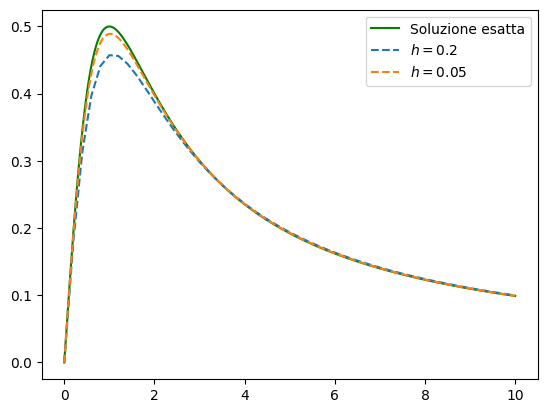

In [35]:
t_h1, u_h1_bkw = eulero_indietro(f, t0, tN, y0, h1)
t_h2, u_h2_bkw = eulero_indietro(f, t0, tN, y0, h2)

plt.figure()
plt.plot(tgrid, y(tgrid), color = 'green', label = 'Soluzione esatta')
plt.plot(t_h1, u_h1_bkw, '--', label = '$h = 0.2$')
plt.plot(t_h2, u_h2_bkw,'--', label = "$h = 0.05$")
plt.legend()
plt.show()

<mark>**Esercizio 3.4**</mark></br>
I confronti grafici sono molto utili, ma è altrettanto utile avere un riscontro quantitativo. Per valutare la bontà dell'approssimazione $u_n\approx y(t_n)$ sull'intera griglia temporale, si può calcolare l'errore globale
</br>
\begin{equation*}
e_{h}=\max_{n=0,\dots,N}\;|y(t_{n})-u_{n}|,
\end{equation*}
dove l'errore dipende dal passo scelto $h>0$. Calcolare l'errore globale per i metodi di **Eulero in avanti e all'indietro** quando $h=0.2,0.05$.


In [37]:
e_h1_fwd = max(abs(u_h1_fwd - y(t_h1)))
e_h2_fwd = max(abs(u_h2_fwd - y(t_h2)))
e_h1_bkw = max(abs(u_h1_bkw - y(t_h1)))
e_h2_bkw = max(abs(u_h2_bkw - y(t_h2)))

print(f"Errore globale h = {h1}: avanti = {e_h1_fwd}, indietro = {e_h1_bkw}\n")
print(f"Errore globale h = {h2}: avanti = {e_h2_fwd}, indietro = {e_h2_bkw}\n")

Errore globale h = 0.2: avanti = 0.05447594159287483, indietro = 0.046833581365646304

Errore globale h = 0.05: avanti = 0.012768857986519333, indietro = 0.012297504715216345



<mark>**Esercizio 3.5**</mark></br>  Calcolare gli errori $e_{h}$ al variare di $h=0.2, 0.1, 0.05, 0.025, 0.0125$, quindi rappresentarne l'andamento utilizzando un opportuno plot in scala logaritmica. I risultati sono coerenti con la teoria?

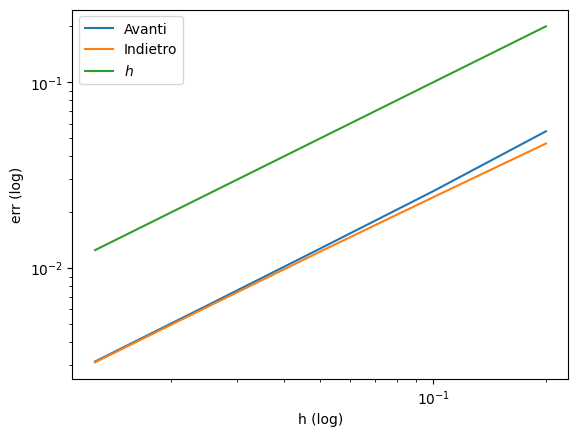

In [43]:
err = {'avanti' : [], 'indietro' : []}
hlist = [0.2, 0.1, 0.05,  0.025, 0.0125]

for h in hlist:
    t_fwd, u_fwd = eulero_avanti(f, t0, tN, y0, h)
    t_bkw, u_bkw = eulero_indietro(f, t0, tN, y0, h)
    err['avanti'].append(max(abs(u_fwd - y(t_fwd))))
    err['indietro'].append(max(abs(u_bkw - y(t_bkw))))

plt.figure()
plt.loglog(hlist, err['avanti'], label = "Avanti")
plt.loglog(hlist, err['indietro'], label = "Indietro")
plt.loglog(hlist, hlist, label = "$h$")
plt.xlabel("h (log)")
plt.ylabel("err (log)")
plt.legend()
plt.show()

<mark>**Esercizio 3.6**</mark></br>
Risolvere il problema con i metodi di **Eulero in avanti** e di **Eulero all'indietro**, scegliendo un passo $h=1$. Riportare su grafici differenti le soluzioni numeriche ottenute, confrontandole con la soluzione esatta e calcolare gli errori ottenuti. Cosa si osserva?


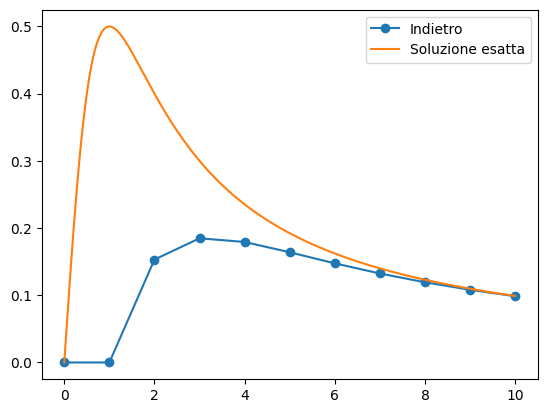

In [46]:
h = 1

t_fwd, u_fwd = eulero_avanti(f, t0, tN, y0, h)
t_bkw, u_bkw = eulero_indietro(f, t0, tN, y0, h)

plt.figure()
#plt.plot(t_fwd, u_fwd,'o-', label = "Avanti")
plt.plot(t_bkw, u_bkw, 'o-', label = "Indietro")
plt.plot(tgrid, y(tgrid), label = "Soluzione esatta")
plt.legend()
plt.show()

# Esercizi per casa

<mark>**Esercizio 4**</mark></br>
In generale, il metodo di Eulero all'indietro è più oneroso (computazionalmente parlando) rispetto alla sua variante in avanti. In aggiunta, più $h$ è piccolo, e più la simulazione richiede tempo (bisogna fare più passi!). Per quantificare tutto ciò, provare a misurare il tempo d'esecuzione richiesto dai due metodi al variare di $h$.
</br>
</br>
*Hint: potete usare la funzione* $\texttt{perf\_counter}$ *del pacchetto* $\texttt{time}$ *per misurare i tempi d'esecuzione del calcolatore.*


Help on built-in function perf_counter in module time:

perf_counter(...)
    perf_counter() -> float

    Performance counter for benchmarking.



<mark>**Esercizio 5**</mark></br>
Un ulteriore metodo *implicito* ad un passo (*one-step*) è il metodo di Crank-Nicolson che possiede il seguente schema iterativo
</br></br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+\frac{h}{2}[f(t_{n},u_{n}) +f(t_{n+1},u_{n+1})] & n=0,\dots,N-1.
\end{cases}
\end{equation*}
</br>
A differenza dei metodi di Eulero in avanti e di Eulero all'indietro, che hanno convergenza lineare questo metodo ha un andamento quadratico.

Considerando sempre il problema di Cauchy
</br></br>
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=\frac{1}{1+t^2}-2y(t)^2 & 0\le t\le 10,\\ y(0)=0,
\end{cases}
\end{equation*}
</br>

la cui soluzione esatta è
\begin{equation*}
y(t)=\frac{t}{1+t^{2}}.
\end{equation*}

Calcolare gli errori </br>
\begin{equation*}
e_{h}=\max_{n=0,\dots,N}\;|y(t_{n})-u_{n}|,
\end{equation*}
al variare di $h=0.2, 0.1, 0.05, 0.025, 0.0125$ e rappresentarne l'andamento utilizzando un opportuno plot in scala logaritmica. I risultati sono coerenti con la teoria?

In [ ]:
from utilis_ODE import crank_nicolson
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# confronto errori 

<mark>**Esercizio 6**</mark></br>
Calcolare il massimo passo $h$ per il seguente problema di Cauchy
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=-3y(t) & 0\le t\le 1,\\ y(0)=1,
\end{cases}
\end{equation*}
la cui soluzione esatta è
\begin{equation*}
y(t)=e^{-3t}.
\end{equation*}
tale per cui il metodo di Eulero in avanti sia assolutemante stabile.